In [30]:
#Importing the Dependencies
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
#Data Collection and Analysis
hd_dataset = pd.read_csv(r"C:\Users\aBC\Downloads\heart_cleveland_upload.csv") 
hd_dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
# number of rows and Columns in this dataset
hd_dataset.shape

(297, 14)

In [ ]:
# getting the statistical measures of the data
hd_dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [ ]:
hd_dataset['condition'].value_counts()
#0 --> Not-Sick
#1 --> Sick

condition
0    160
1    137
Name: count, dtype: int64

In [ ]:
hd_dataset.groupby('condition').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
condition,,,,,,,,,,,,,
0,52.643750,0.556250,1.793750,129.175000,243.493750,0.143750,0.843750,158.581250,0.143750,0.598750,0.412500,0.275000,0.375000
1,56.759124,0.817518,2.583942,134.635036,251.854015,0.145985,1.175182,139.109489,0.540146,1.589051,0.824818,1.145985,1.372263


In [ ]:

duplicates = hd_dataset.duplicated()
print(hd_dataset[duplicates])
print(f"Number of duplicate rows: {duplicates.sum()}")



Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, condition]
Index: []
Number of duplicate rows: 0


In [ ]:
X = hd_dataset.drop(columns='condition', axis=1)
Y = hd_dataset['condition']


In [38]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     69    1   0       160   234    1        2      131      0      0.1   
1     69    0   0       140   239    0        0      151      0      1.8   
2     66    0   0       150   226    0        0      114      0      2.6   
3     65    1   0       138   282    1        2      174      0      1.4   
4     64    1   0       110   211    0        2      144      1      1.8   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
292   40    1   3       152   223    0        0      181      0      0.0   
293   39    1   3       118   219    0        0      140      0      1.2   
294   35    1   3       120   198    0        0      130      1      1.6   
295   35    0   3       138   183    0        0      182      0      1.4   
296   35    1   3       126   282    0        2      156      1      0.0   

     slope  ca  thal  
0        1   1     0  
1        0   2     0  
2        2   0    

In [39]:
print(Y)

0      0
1      0
2      0
3      1
4      0
      ..
292    1
293    1
294    1
295    0
296    1
Name: condition, Length: 297, dtype: int64


               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.092399  0.110471  0.290476  0.202644  0.132062   
sex      -0.092399  1.000000  0.008908 -0.066340 -0.198089  0.038850   
cp        0.110471  0.008908  1.000000 -0.036980  0.072088 -0.057663   
trestbps  0.290476 -0.066340 -0.036980  1.000000  0.131536  0.180860   
chol      0.202644 -0.198089  0.072088  0.131536  1.000000  0.012708   
fbs       0.132062  0.038850 -0.057663  0.180860  0.012708  1.000000   
restecg   0.149917  0.033897  0.063905  0.149242  0.165046  0.068831   
thalach  -0.394563 -0.060496 -0.339308 -0.049108 -0.000075 -0.007842   
exang     0.096489  0.143581  0.377525  0.066691  0.059339 -0.000893   
oldpeak   0.197123  0.106567  0.203244  0.191243  0.038596  0.008311   
slope     0.159405  0.033345  0.151079  0.121172 -0.009215  0.047819   
ca        0.362210  0.091925  0.235644  0.097954  0.115945  0.152086   
thal      0.120795  0.370556  0.266275  0.130612  0.023441  0.05

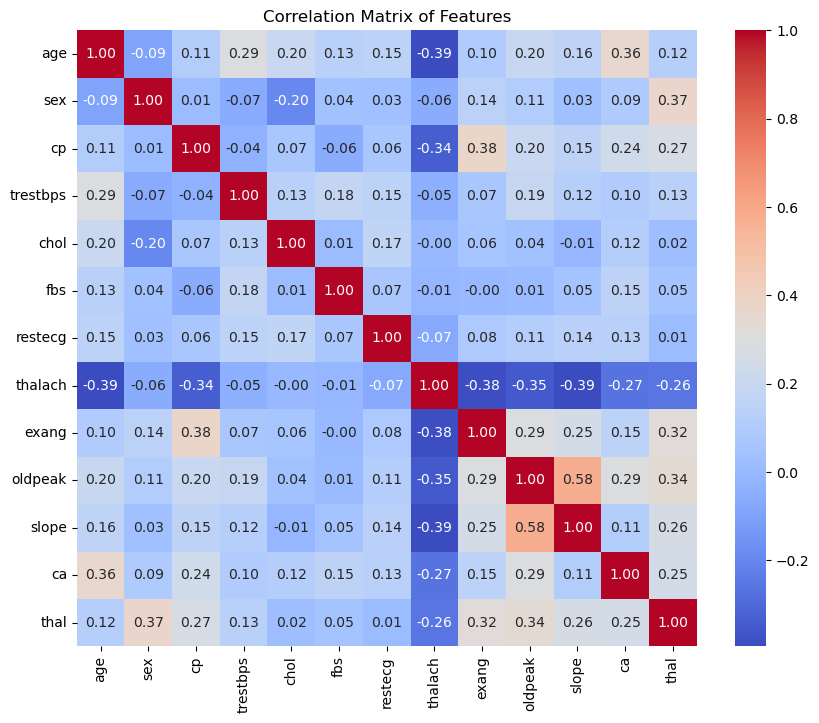

In [41]:
#Compute correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr()



print(corr_matrix)



plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

In [42]:
scaler = StandardScaler()
scaler.fit(X)
standardized_data = scaler.transform(X)



print(standardized_data)

[[ 1.60030243  0.69109474 -2.24062879 ...  0.6437811   0.34482438
  -0.87429153]
 [ 1.60030243 -1.44697961 -2.24062879 ... -0.97658319  1.41162482
  -0.87429153]
 [ 1.26824154 -1.44697961 -2.24062879 ...  2.26414539 -0.72197605
  -0.87429153]
 ...
 [-2.16305433  0.69109474  0.87388018 ...  0.6437811  -0.72197605
   1.21977769]
 [-2.16305433 -1.44697961  0.87388018 ... -0.97658319 -0.72197605
  -0.87429153]
 [-2.16305433  0.69109474  0.87388018 ... -0.97658319 -0.72197605
   1.21977769]]


In [ ]:
X = standardized_data
Y = hd_dataset['condition']

In [44]:
print(X)
print(Y)

[[ 1.60030243  0.69109474 -2.24062879 ...  0.6437811   0.34482438
  -0.87429153]
 [ 1.60030243 -1.44697961 -2.24062879 ... -0.97658319  1.41162482
  -0.87429153]
 [ 1.26824154 -1.44697961 -2.24062879 ...  2.26414539 -0.72197605
  -0.87429153]
 ...
 [-2.16305433  0.69109474  0.87388018 ...  0.6437811  -0.72197605
   1.21977769]
 [-2.16305433 -1.44697961  0.87388018 ... -0.97658319 -0.72197605
  -0.87429153]
 [-2.16305433  0.69109474  0.87388018 ... -0.97658319 -0.72197605
   1.21977769]]
0      0
1      0
2      0
3      1
4      0
      ..
292    1
293    1
294    1
295    0
296    1
Name: condition, Length: 297, dtype: int64


In [45]:
print(X.shape, Y.shape)
print(Y.value_counts())

(297, 13) (297,)
condition
0    160
1    137
Name: count, dtype: int64


In [46]:
#Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(297, 13) (237, 13) (60, 13)


In [47]:
#Training the Model
classifier = svm.SVC(kernel='rbf', C=0.3)



In [48]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

SVC(C=0.3)

In [49]:
#Model Evaluation
# accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [50]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.8818565400843882


In [51]:
# accuracy score on the test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [52]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.8666666666666667


In [ ]:
#Making a Predictive System
input_data = (1,89,66,23,94,28.1,0.167,21)
#(5,166,72,19,175,25.8,0.587,51)
# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

In [24]:
y_pred = classifier.predict(X_test)



cm = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix:")
print(cm)



print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Confusion Matrix:
[[29  3]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60

